In [1]:
!pip install plotly

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.6/15.6 MB 34.5 MB/s eta 0:00:0000:0100:01


In [2]:
!pip install "anywidget>=0.9.13"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.7/213.7 kB 5.0 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 2.2 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 477.3/477.3 kB 11.3 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 14.6 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 20.0 MB/s eta 0:00:0000:01


In [3]:
!pip install -U kaleido

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 11.4 MB/s eta 0:00:0000:0100:01


In [4]:
!pip install anndata==0.8.0

In [2]:
def gexpnorm(adata, gene_dict,level, gl, fin_name):
    present = [g for g in gl if g in gene_dict]
    missing = [g for g in gl if g not in gene_dict]
    gi = [gene_dict[i] for i in present]
    exp = adata[:,gi].X.A
    expr = pd.DataFrame(exp,columns = present, index = adata.obs_names)
    expr["cell_type"] = adata.obs[level].values
    mean_expr = expr.groupby("cell_type").mean()
    frac_expr = expr.groupby("cell_type").apply(
    lambda x: (x > 0).mean())
    mean_expr_norm = (mean_expr - mean_expr.min()) / (
    mean_expr.max() - mean_expr.min())
    for g in missing:
        mean_expr_norm[g] = 0
        frac_expr[g] = 0
    mean_expr_norm = mean_expr_norm[gl]
    frac_expr = frac_expr[gl]
    mean_expr_norm.columns = fin_name
    frac_expr.columns = fin_name
    return(mean_expr_norm, frac_expr)

In [3]:
def orthogroup_mapper(orthogroups, label):
    mapping = {}
    for index in orthogroups.index:
        gene_list = orthogroups.loc[index, label]
        if type(gene_list) != float:
            genes = gene_list.split(',')
            for item in genes:
                mapping[item] = index
    return(mapping)

In [4]:
def pull_gene(val):
    if type(val) != str:
        return(val)
    else:
        return(val.split(',')[0])

In [1]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from scipy.stats import poisson
from sklearn.neighbors import KernelDensity
import time
import dill
from scipy.optimize import minimize
import pickle
import itertools
import os
import anndata as ad
import math
import csv
import plotly.express as px
from sklearn.manifold import TSNE

In [5]:
sm = load_samap('Active_SAMap_Joined/sm_hyporirv_mnpo_05202026.pkl')

In [6]:
fn = 'Subclustering/MNPO/SAM_MO_soupx_plus5_cleaned_MNPO_08182025.h5ad'
sam_mo = SAM()
sam_mo.load_data(fn)
gene_dict_mo = {}
for i in range(len(sam_mo.adata.var_names)):
    gene_dict_mo[sam_mo.adata.var_names[i]] = i
gene_dict_mo['NaN'] = 'NaN'

In [7]:
fn = 'Subclustering/MNPO/SAM_CJ_joined_v2_cleaned_08182025_MNPO.h5ad'
sam_cj = SAM()
sam_cj.load_data(fn)
gene_dict_cj = {}
for i in range(len(sam_cj.adata.var_names)):
    gene_dict_cj[sam_cj.adata.var_names[i]] = i
gene_dict_cj['NaN'] = 'NaN'

In [8]:
fn = 'Subclustering/MNPO/SAM_AC_ncbi_soupx_cleaned_08182025_MNPO.h5ad'
sam_ac = SAM()
sam_ac.load_data(fn)
gene_dict_ac = {}
for i in range(len(sam_ac.adata.var_names)):
    gene_dict_ac[sam_ac.adata.var_names[i]] = i
gene_dict_ac['NaN'] = 'NaN'

In [89]:
sam_mg = SAM()
sam_mg.load_data('Subclustering/MNPO/SAM_Allen_Institute_MNPO.h5ad')
gene_dict_mg = {}
for i in range(len(sam_mg.adata.var_names)):
    gene_dict_mg[sam_mg.adata.var_names[i]] = i
gene_dict_mg['NaN'] = 'NaN'

In [37]:
sam_ri = SAM()
sam_ri.load_data('Subclustering/MNPO/RI_116_AVPV-MEPO-SFO_Tbr1_Glut_ss_subclass_crossed_nn_04282026.h5ad')
gene_dict_ri = {}
for i in range(len(sam_ri.adata.var_names)):
    gene_dict_ri[sam_ri.adata.var_names[i]] = i
gene_dict_ri['NaN'] = 'NaN'

In [38]:
orthogroups = pd.read_csv('Vert_emapper_allorgs_12302025.csv', index_col = 'Unnamed: 0')
mg_mapping_ortho = orthogroup_mapper(orthogroups, 'MM')
mo_mapping_ortho = orthogroup_mapper(orthogroups, 'MO')
cj_mapping_ortho = orthogroup_mapper(orthogroups, 'CJ')
ac_mapping_ortho = orthogroup_mapper(orthogroups, 'AC')
ri_mapping_ortho = orthogroup_mapper(orthogroups,'RI')

In [39]:
otohomo = pd.read_csv('OTO_star_mouseanchored_missing_le2_expthresh_07062026.tsv',delimiter='\t',index_col = 'MM')

In [40]:
otohomo.loc['Slc2a9',:]

MO             Slc2a9
CJ             SLC2A9
AC             slc2a9
XT           slc2a15a
DR           slc2a9l2
n_species           6
Name: Slc2a9, dtype: object

In [41]:
orthogroups.loc[mg_mapping_ortho['Slc2a9'],:]

MM      Slc2a9
MO      Slc2a9
CJ      SLC2A9
AC      slc2a9
XT    slc2a15a
DR    slc2a9l2
MV      Slc2a9
CC      SLC2A9
RV      SLC2A9
CA    slc2a9l2
RI      SLC2A9
Name: 4913Z@7742, dtype: object

In [42]:
mg_names = ['Etv1','Onecut1','Bcl11a','Foxp2','Ebf1','Emx2','Adcyap1','Agtr1a','Rxfp1','Crh','Trpc3','Sncg', 'Opn5','Rxfp2','Npy','Brs3','Ucn3','Slc2a9']
mg_names.reverse()

mg_genes = ['Etv1','Onecut1','Bcl11a','Foxp2','Ebf1','Emx2','Adcyap1','Agtr1a','Rxfp1','Crh','Trpc3','Sncg', 'Opn5','Rxfp2','Npy','Brs3','Ucn3','Slc2a9']
mg_genes.reverse()

mo_genes = ['Etv1','Onecut1','Bcl11a','Foxp2','Ebf1','Emx2','Adcyap1','ENSMOCG00000019499','Rxfp1','Crh','Trpc3','Sncg', 'Opn5','Rxfp2','Npy','Brs3','UCN3','Slc2a9']
mo_genes.reverse()

cj_genes = ['ETV1','ONECUT1','BCL11A','FOXP2','EBF1','EMX2','ADCYAP1','AGTR1','RXFP1','CRH','TRPC3','SNCG','OPN5','ENSCJPG00005003031','NPY','BRS3','UCN3','SLC2A9']
cj_genes.reverse()

ac_genes = ['etv1','bcl11a','ebf1','emx2','adcyap1','rxfp1','crh','trpc3','sncg','LOC100554017','LOC100553533','npy','brs3','ucn3','slc2a9']
ac_genes.reverse()

ri_genes = ['LOC138641708','ONECUT1','BCL11A','FOXP2','EBF1','EMX2','ADCYAP1','LOC138638365','RXFP1','CRH','TRPC3','SNCG', 'OPN5','RXFP2','NPY','BRS3','UCN3','SLC2A9']
ri_genes.reverse()

In [43]:
mg_names

['Slc2a9',
 'Ucn3',
 'Brs3',
 'Npy',
 'Rxfp2',
 'Opn5',
 'Sncg',
 'Trpc3',
 'Crh',
 'Rxfp1',
 'Agtr1a',
 'Adcyap1',
 'Emx2',
 'Ebf1',
 'Foxp2',
 'Bcl11a',
 'Onecut1',
 'Etv1']

In [66]:
sam_mg.adata.obs['eq_supertype_cl_v2'] = sm.sams['mg'].adata.obs['eq_supertype_cl_v2']

In [67]:
mean_expr_norm_mg, frac_mg = gexpnorm(sam_mg.adata,gene_dict_mg,'eq_supertype_cl_v2',
                             mg_genes,
                            mg_names)
mean_expr_norm_mo, frac_mo = gexpnorm(sam_mo.adata,gene_dict_mo,'eq_supertype_cl_v2',
                             mo_genes,
                            mg_names)
mean_expr_norm_cj, frac_cj = gexpnorm(sam_cj.adata,gene_dict_cj,'eq_supertype_cl_v2',
                             cj_genes,
                            mg_names)
mean_expr_norm_ac, frac_ac = gexpnorm(sam_ac.adata,gene_dict_ac,'eq_supertype_cl_v2',
                             ac_genes,
                            ['Slc2a9','Ucn3','Brs3','Npy','Rxfp2','Opn5','Sncg','Trpc3','Crh','Rxfp1','Adcyap1','Emx2','Ebf1','Bcl11a','Etv1'])
mean_expr_norm_ri, frac_ri = gexpnorm(sam_ri.adata,gene_dict_ri,'eq_supertype_cl_v2',
                             ri_genes,
                            mg_names)

In [68]:
test = [mg_genes,mo_genes,cj_genes,ac_genes,ri_genes]
df = pd.DataFrame(test,index = ['Mouse names','Vole names','Quail names','Anole names','Imitator frog names']).T

In [69]:
df.to_csv('Genes_MNPO_mapping_allorgs_Fig6B_0702026.csv')

In [70]:
mean_expr_norm_mg.index

Index(['MM_Brs3', 'MM_Foxp2_1', 'MM_Foxp2_2', 'MM_Thirst', 'MM_Warmth'], dtype='object', name='cell_type')

In [71]:
frac_mg

,Slc2a9,Ucn3,Brs3,Npy,Rxfp2,Opn5,Sncg,Trpc3,Crh,Rxfp1,Agtr1a,Adcyap1,Emx2,Ebf1,Foxp2,Bcl11a,Onecut1,Etv1
cell_type,,,,,,,,,,,,,,,,,,
MM_Brs3,0.018987,0.312236,0.411392,0.014768,0.006329,0.204641,0.018987,0.337553,0.008439,0.000000,0.002110,0.394515,0.784810,0.021097,0.031646,0.078059,0.160338,0.016878
MM_Foxp2_1,0.001916,0.001916,0.013410,0.007663,0.013410,0.003831,0.005747,0.180077,0.001916,0.001916,0.042146,0.111111,0.216475,0.024904,0.636015,0.204981,0.005747,0.296935
MM_Foxp2_2,0.009901,0.000000,0.004950,0.019802,0.049505,0.039604,0.034653,0.059406,0.014851,0.004950,0.099010,0.717822,0.341584,0.980198,0.752475,0.341584,0.282178,0.638614
MM_Thirst,0.039130,0.000000,0.001449,0.010145,0.002899,0.000000,0.323188,0.211594,0.005797,0.268116,0.575362,0.802899,0.518841,0.055072,0.134783,0.036232,0.294203,0.904348
MM_Warmth,0.066298,0.001105,0.024309,0.009945,0.278453,0.497238,0.668508,0.677348,0.005525,0.012155,0.192265,0.703867,0.361326,0.007735,0.047514,0.542541,0.674033,0.369061


In [72]:
mean_expr_norm_mg.index

Index(['MM_Brs3', 'MM_Foxp2_1', 'MM_Foxp2_2', 'MM_Thirst', 'MM_Warmth'], dtype='object', name='cell_type')

In [49]:
mean_expr_norm_mo.index

CategoricalIndex(['6', 'MM_Brs3', 'MM_Foxp2_1', 'MM_Foxp2_2', 'MM_Thirst',
                  'MM_Warmth'],
                 categories=['6', 'MM_Brs3', 'MM_Foxp2_1', 'MM_Foxp2_2', 'MM_Thirst', 'MM_Warmth'], ordered=False, dtype='category', name='cell_type')

In [73]:
mean_expr_norm_cj.index

CategoricalIndex(['MM_Brs3', 'MM_Foxp2_1', 'MM_Thirst', 'MM_Warmth'], categories=['MM_Brs3', 'MM_Foxp2_1', 'MM_Thirst', 'MM_Warmth'], ordered=False, dtype='category', name='cell_type')

In [74]:
mean_expr_norm_ac.index

CategoricalIndex(['2', 'MM_Foxp2_2', 'MM_Thirst', 'MM_Warmth'], categories=['2', 'MM_Foxp2_2', 'MM_Thirst', 'MM_Warmth'], ordered=False, dtype='category', name='cell_type')

In [75]:
mean_expr_norm_ri.index

CategoricalIndex(['5', '6', 'MM_Brs3', 'MM_Foxp2_1', 'MM_Thirst', 'MM_Warmth'], categories=['5', '6', 'MM_Brs3', 'MM_Foxp2_1', 'MM_Thirst', 'MM_Warmth'], ordered=False, dtype='category', name='cell_type')

In [76]:
df = pd.DataFrame(columns = ['celltype','gene','avg exp','frac'])

In [77]:
mgl = []
for ct in mean_expr_norm_mg.index:
    for g in mean_expr_norm_mg.columns:
        mgl.append(['mg_'+ct,g,mean_expr_norm_mg.loc[ct,g],frac_mg.loc[ct,g]])

mol = []
for ct in mean_expr_norm_mo.index:
    for g in mean_expr_norm_mo.columns:
        mol.append(['mo_'+ct,g,mean_expr_norm_mo.loc[ct,g],frac_mo.loc[ct,g]])
        
cjl = []
for ct in mean_expr_norm_cj.index:
    for g in mean_expr_norm_cj.columns:
        cjl.append(['cj_'+ct,g,mean_expr_norm_cj.loc[ct,g],frac_cj.loc[ct,g]])
        
acl = []
for ct in mean_expr_norm_ac.index:
    for g in mean_expr_norm_ac.columns:
        acl.append(['ac_'+ct,g,mean_expr_norm_ac.loc[ct,g],frac_ac.loc[ct,g]])
        
ril = []
for ct in mean_expr_norm_ri.index:
    for g in mean_expr_norm_ri.columns:
        ril.append(['ri_'+ct,g,mean_expr_norm_ri.loc[ct,g],frac_ri.loc[ct,g]])

In [78]:
mgdf = pd.DataFrame(data = mgl,columns = ['celltype','gene','avg exp','frac'])
modf = pd.DataFrame(data = mol,columns = ['celltype','gene','avg exp','frac'])
cjdf = pd.DataFrame(data = cjl,columns = ['celltype','gene','avg exp','frac'])
acdf = pd.DataFrame(data = acl,columns = ['celltype','gene','avg exp','frac'])
ridf = pd.DataFrame(data = ril,columns = ['celltype','gene','avg exp','frac'])

In [79]:
df = pd.concat([mgdf,modf,cjdf,acdf,ridf],axis = 0)

In [80]:
df = df.fillna(0)

In [81]:
df = df[~df['celltype'].isin(['mo_6','ac_2','ri_5','ri_6'])]

In [82]:
test = [0,.1,.25,.4,.75,1]
fin_ct = []
fin_gene = []
avg_exp = []
frac = []
for th in test:
    for item in df['celltype'].unique():
        fin_ct.append(item)
        fin_gene.append('test_' + str(th))
        avg_exp.append(1)
        frac.append(th)

In [83]:
test_df = pd.DataFrame([fin_ct,fin_gene,avg_exp,frac], index = ['celltype','gene','avg exp','frac']).T

In [84]:
df = pd.concat([df,test_df])

In [85]:
df['frac'] = df['frac'].astype(float)
df['avg exp'] = df['avg exp'].astype(float)

In [86]:
df['frac'] =  df['frac'].clip(upper=.4)

In [87]:
fig = px.scatter(df, x = 'celltype', y = 'gene', size = 'frac', color = 'avg exp', color_continuous_scale= 'Blues', range_color=[0,.99],opacity = 1)
fig.update_xaxes(categoryorder='array', categoryarray= ['mg_MM_Thirst','mo_MM_Thirst','cj_MM_Thirst','ac_MM_Thirst','ri_MM_Thirst',
          'mg_MM_Warmth', 'mo_MM_Warmth','cj_MM_Warmth','ac_MM_Warmth', 'ri_MM_Warmth',
          'mg_MM_Foxp2_1','mo_MM_Foxp2_1','cj_MM_Foxp2_1','ri_MM_Foxp2_1','mg_MM_Foxp2_2','mo_MM_Foxp2_2','ac_MM_Foxp2_2',
          'mg_MM_Brs3','mo_MM_Brs3','cj_MM_Brs3','ri_MM_Brs3'],
                range=[-0.5, len(df["celltype"].unique()) - 0.5])
fig.update_layout(
    autosize=False,
    width=1000,
    height=750,
)

max_size = 15

fig.update_traces(
    marker=dict(
        sizemode="area",
        sizeref=df["frac"].max() / max_size**2
    )
)

fig.update_xaxes(
    showgrid=False,
    showline=True,
    linewidth=1,
    linecolor="black",
    mirror=True,
)

fig.update_yaxes(
    showgrid=False,
    showline=True,
    linewidth=1,
    linecolor="black",
    mirror=True,
)
fig.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="white",
)
fig.write_image("Figures/Figures_07072026/MNPO_dotplot_norm_withtestmarkers_v2_07072026.pdf")
fig.write_image("Figures/Figures_07072026/MNPO_dotplot_norm_withtestmarkers_v2_07072026.svg")

<AxesSubplot:>

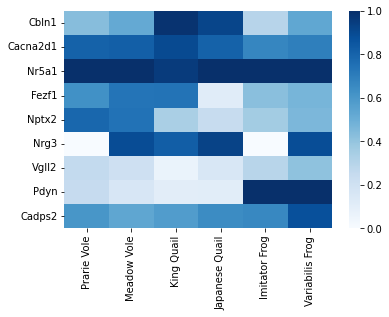

In [85]:
sns.heatmap(plt_df, cmap = 'Blues')

In [61]:
mean_expr_norm_mo

Cbln1       0.431585
Cacna2d1    0.805162
Nr5a1       1.000000
Fezf1       0.628466
Nptx2       0.788665
Nrg3             NaN
Vgll2       0.257869
Pdyn        0.252158
Cadps2      0.608813
Name: 129 VMH Nr5a1 Glut, dtype: float32

In [59]:
mean_expr_norm_mv

Cbln1       0.523176
Cacna2d1    0.817181
Nr5a1       1.000000
Fezf1       0.736854
Nptx2       0.742303
Nrg3        0.891075
Vgll2       0.209099
Pdyn        0.163485
Cadps2      0.536706
Name: 129 VMH Nr5a1 Glut, dtype: float32

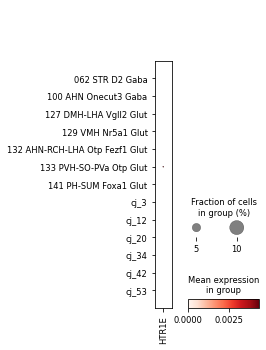

In [65]:
sc.pl.dotplot(sam_cj.adata, ['HTR1E'], groupby = 'subclass_id_label_mapping_nounlabeled')